# Detecting Tipping Points with Ammonyte LERM Method

## Overview

This notebook demonstrates the application of the **LERM (Laplacian Eigenmaps of Recurrence Matrices)** from the [Ammonyte](https://github.com/LinkedEarth/Ammonyte) package for detecting abrupt climate transitions in paleoclimate time series. LERM uses **Fisher Information** to identify rapid shifts in Earth's climate system.

## Scientific Background

### What is LERM?
The **Laplacian Eigenmaps of Recurrence Matrices (LERM)** is a nonlinear time series analysis technique that:
- Converts time series data into a **time-embedded phase space** using delay embedding
- Constructs a **recurrence network** to capture temporal dependencies
- Computes **Fisher Information** through Laplacian eigenmaps
- Detects transitions by identifying when Fisher Information crosses confidence bounds

## Reference

James, A., Emile-Geay, J., Malik, N., & Khider, D. (2024). Detecting Paleoclimate Transitions With Laplacian Eigenmaps of Recurrence Matrices (LERM). *Paleoceanography and Paleoclimatology*. https://doi.org/10.1029/2023PA004700

In [1]:
# Import libraries and packages
import ammonyte as amt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy 

### Load the NGRIP Dataset for Tipping Point Analysis

### Dataset Overview
The **North Greenland Ice Core Project (NGRIP)** dataset contains high-resolution paleoclimate proxy data from Greenland ice cores. This dataset is particularly valuable for studying abrupt climate transitions and tipping points in the Earth's climate system.

**Key Dataset Features:**
- **Proxy Variable**: $\mathrm{\delta^{18}O}$ isotope measurements
- **Units**: per mil
- **Time Scale**: Thousands of years before present (kyr b2k)

In [2]:
ngrip = amt.Series.from_csv('data/NGRIP.csv')

Time axis values sorted in ascending order
Time axis values sorted in ascending order


In [3]:
# These arrays will be used to create fresh Series objects in Part 2
ngrip_time_original = ngrip.time.copy()
ngrip_value_original = ngrip.value.copy()

### Dataset Metadata Summary

Display key metadata information from the loaded NGRIP time series to understand the dataset characteristics.

In [4]:
# The metadata
print(f"Loaded NGRIP dataset: {ngrip.label}")
print(f"Time range: {ngrip.time.min():.2f} - {ngrip.time.max():.2f} {ngrip.time_unit}")
print(f"Number of data points: {len(ngrip.time)}")
print(f"Value range: {ngrip.value.min():.2f} - {ngrip.value.max():.2f} {ngrip.value_unit}")

Loaded NGRIP dataset: NGRIP Ice Core Data
Time range: 0.05 - 122.27 kyr b2k
Number of data points: 6112
Value range: -46.50 - -32.11 per mill


### NGRIP $\mathrm{\delta^{18}O}$ Record Visualization
The plot below shows the complete NGRIP ice core record, where:
- **X-axis**: Time in thousands of years before present (kyr b2k)
- **Y-axis**: $\mathrm{\delta^{18}O}$ isotope values in per mil 
- **Interpretation**: More negative values indicate colder conditions

(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='Age [kyr b2k]', ylabel='δ18O [%] [per mill]'>)

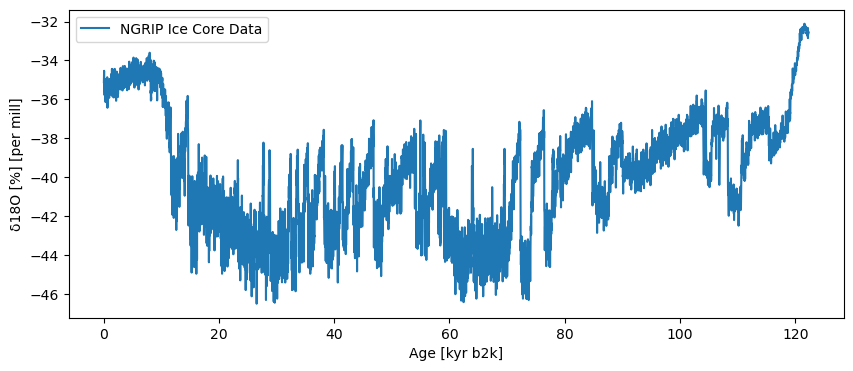

In [5]:
# Plot NGRIP series
ngrip.plot() 

# Part 1: Main LERM Analysis

This section demonstrates the complete LERM workflow for detecting climate transitions in the NGRIP dataset. We use **block_size=3** for smoothing Fisher Information throughout this analysis.

**Workflow Steps:**
1. Time Delay Embedding - Transform 1D time series into multi-dimensional phase space
2. Recurrence Network Construction - Build network representation of climate dynamics
3. Fisher Information Computation - Extract dynamical information via Laplacian Eigenmaps
4. Smoothing - Apply block averaging to reduce noise (block_size=3)
5. Visualization - Display smoothed Fisher Information 
6. Transition Detection - Apply LERM method to identify climate transitions
7. Results Visualization - Show detected transitions on both Fisher Information and NGRIP data
8. Alternative Method - Apply KS test for comparison

## Step 1: Time Delay Embedding

#### Phase Space Reconstruction
To apply the LERM method, we first transform the 1-dimensional time series into a **multi-dimensional phase space**.

**Key Parameters:**
- **`m` (embedding dimension)**: The number of dimensions in the reconstructed phase space
- **`tau` (time delay)**: The lag between successive coordinates in the embedded space
    - Automatically computed to optimize reconstruction
    - Represents the decorrelation timescale of the system

In [6]:
#series to time embedded series
m = 7
NGRIP_td = amt.TimeEmbeddedSeries(ngrip , m)
NGRIP_td.tau

11

## Step 2: Recurrence Network Construction
#### Finding the Optimal Epsilon Parameter
Before constructing the recurrence network, we need to determine the optimal **epsilon (ε)** value, which defines the neighborhood radius for connecting points in the phase space. The algorithm iteratively adjusts epsilon until the recurrence network 
  achieves the target density.

**Method:** Adaptive epsilon search to achieve target network density

**Parameters:**
- **`eps`**: Initial epsilon value to start the search (1.0)
- **`target_density`**: Desired density of the recurrence network (0.05 = 5\%)
- **`tolerance`**: Acceptable deviation from target density (0.01 = 1\%, meaning it Stops search when density is within [4\%, 6\%])
- **`amp`**: Amplitude scaling factor for the search (30, Controls the step size during epsilon optimization)


In [7]:
NGRIP_epsilon = NGRIP_td.find_epsilon(eps=1,target_density=.05,tolerance=.01,amp=30)

Initial density is 0.0018
Initial density is not within the tolerance window, searching...
Epsilon: 2.4466, Density: 0.0369
Epsilon: 2.8386, Density: 0.0533
Epsilon: 2.8386, Density: 0.0533.


### Recurrence Matrices Visualization
#### Extracting and Visualizing the Recurrence Network

**What is a Recurrence Matrices?**
- A binary Matrices where entry (i,j) = 1 if points i and j are "close" in phase space (within epsilon distance)

**Interpretation**
- **Dense black regions**: Stable climate states with high recurrence
  (stadials or interstadials)
- **White/sparse regions**: Transitional periods, rapid changes, or unique states **Tipping points occur here**
- **Black diagonal lines**: Similar evolution patterns at different times
- **Black vertical/horizontal lines**: Frequently recurring climate states

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Recurrence Matrices'}, xlabel='Age kyr b2k', ylabel='Age kyr b2k'>)

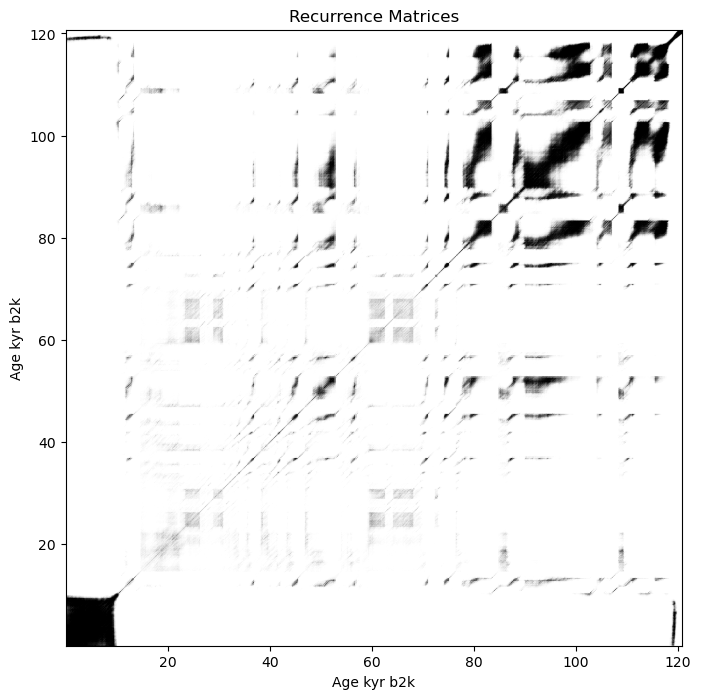

In [8]:
NGRIP_rm = NGRIP_epsilon['Output']
# plot the recurrence Matrices
NGRIP_rm.plot(title = 'Recurrence Matrices')

## Step 3: Fisher Information Computation
#### Extracting Dynamical Information from the Recurrence Network
The **Laplacian Eigenmaps** method computes **Fisher Information** from
the recurrence network using a sliding window approach. Fisher Information quantifies how much information the system's trajectory carries about its underlying dynamics and serves as an early warning signal for tipping points.

**Parameters:**
- **`w_size`**: Window size (20 time steps)
    - Size of the sliding window for local Fisher Information computation
- **`w_incre`**: Window increment (4 time steps)
    - Step size for moving the window along the time series

**Fisher Information Interpretation:**
  - **High Fisher Information**: System is near a critical transition
  - **Low Fisher Information**: System is stable

In [9]:
NGRIP_lp = NGRIP_rm.laplacian_eigenmaps(w_size=20,w_incre=4)

## Step 4: Smoothing the Fisher Information Series

The raw Fisher Information signal can contain high-frequency noise that may lead to false positive transition detections. We apply **block averaging** to smooth the series while preserving the timing and magnitude of genuine transitions.

**Method:** Block averaging with sliding window

**Parameters:**
- **`block_size`**: Size of the averaging window (3 time steps)

In [10]:
NGRIP_lp_smooth = amt.utils.fisher.smooth_series(series=NGRIP_lp, block_size=2)

## Step 5: Visualizing Smoothed Fisher Information

This visualization displays the **smoothed Fisher Information**.

**Plot elements:**
- **Blue line**: Smoothed Fisher Information 


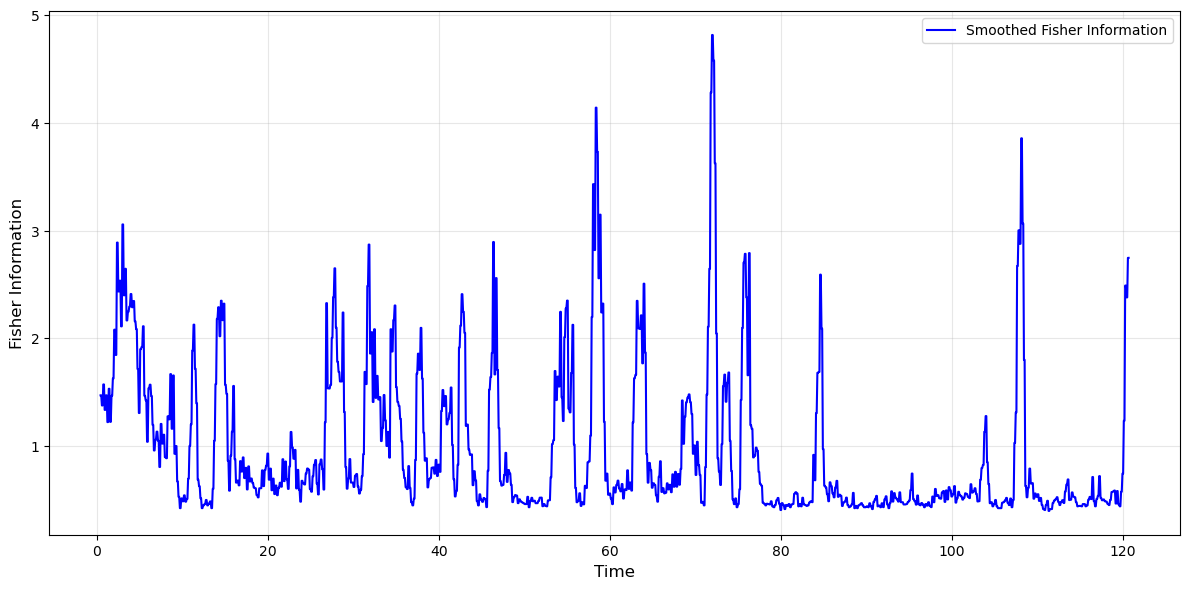

In [11]:
fig, ax = plt.subplots(figsize=(12,6))
NGRIP_lp_smooth.plot(ax=ax, color='blue',linewidth=1.5, label = 'Smoothed Fisher Information')

ax.set_xlabel('Time',fontsize=12)
ax.set_ylabel('Fisher Information',fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Step 6: Detecting Climate Transitions with LERM

The `lerm_transitions()` method performs **deterministic transition detection** on the Fisher Information series. This is a key distinction:

- **What's being analyzed**: The smoothed Fisher Information (`NGRIP_lp_smooth`)
- **Why**: Fisher Information is sensitive to dynamical changes and serves as an indicator of system transitions
- **Output**: Specific times where the system crosses critical thresholds

The LERM method identifies transitions by:
1. Computing **adaptive thresholds** from the Fisher Information distribution
- Upper threshold (95th percentile): Marks significant upward changes
- Lower threshold (5th percentile): Marks significant downward changes
2. Detecting **crossings** where Fisher Information exceeds these bounds
3. Classifying each transition as:
- **Upward (+1)**: System moving toward instability or rapid change
- **Downward (-1)**: System returning to stability

In [12]:
transitions = NGRIP_lp_smooth.lerm_transitions()
print(transitions)

Deterministic Transition Detection Results - NGRIP Ice Core Data
+----------+---------------------+----------------+------------------+---------------------+
| Method   |   Total Transitions |   Upward Jumps |   Downward Jumps | Series Label        |
+==========+=====================+================+==================+=====================+
| LERM     |                  31 |             15 |               16 | NGRIP Ice Core Data |
+----------+---------------------+----------------+------------------+---------------------+

Transition Details:
  1. Time: 9.43 kyr b2k, Direction: Upward
  2. Time: 11.43 kyr b2k, Direction: Downward
  3. Time: 12.43 kyr b2k, Direction: Upward
  4. Time: 14.43 kyr b2k, Direction: Downward
  5. Time: 15.43 kyr b2k, Direction: Upward
  6. Time: 27.43 kyr b2k, Direction: Downward
  7. Time: 29.43 kyr b2k, Direction: Upward
  8. Time: 31.43 kyr b2k, Direction: Downward
  9. Time: 36.43 kyr b2k, Direction: Upward
  10. Time: 37.43 kyr b2k, Direction: Downward

In [13]:
# Define D/O event chronologies as numpy arrays for analysis
do_events = pd.read_csv('../ammonyte/data/DO_events.csv', comment = '#')


main_do_events = do_events['main_kyr_b2k'].dropna().values
print(len(main_do_events)) # The length of main DO events 

all_do_events = do_events['all_kyr_b2k'].dropna().values
print(len(all_do_events))  # The length of all DO events

upward_mask = transitions.jump_values == 1
detected_times = transitions.jump_times[upward_mask]                          
detected_times = detected_times[~np.isnan(detected_times)]
tolerance = 0.5

results = amt.utils.evaluate_detection(detected_times, main_do_events, tolerance=0.5)   
print(results)

25
73
Detection Evaluation Metrics
Metrics calculated within tolerance = 0.5

Performance Scores:
+-----------+---------+
| Metric    |   Value |
+===========+=========+
| Precision |  0.2667 |
+-----------+---------+
| Recall    |  0.16   |
+-----------+---------+
| F1 Score  |  0.2    |
+-----------+---------+

Detection Counts:
+-----------------+---------+
| Category        |   Count |
+=================+=========+
| True Positives  |       4 |
+-----------------+---------+
| False Positives |      11 |
+-----------------+---------+
| False Negatives |      21 |
+-----------------+---------+

Summary:
  Detected: 15 | Ground Truth: 25



## Step 7: Visualizing Detected Transitions

This visualization demonstrates the **complete LERM workflow** by combining the Fisher Information and original climate data on a single plot with dual y-axes.

**Plot Elements:**                                                            
                                                                            
- **Black line (left y-axis)**: Original NGRIP $\delta^{18}O$ climate record  
- More negative values indicate colder conditions                           
                                                                            
- **Green line (right y-axis)**: Smoothed Fisher Information                  
- High values indicate the system is undergoing rapid dynamical changes     
- Serves as the indicator for detecting transitions                         
                                                                            
- **Red vertical lines**: Upward transitions (system moving toward instability )                                                                 
- **Blue vertical lines**: Downward transitions (system returning to stability)


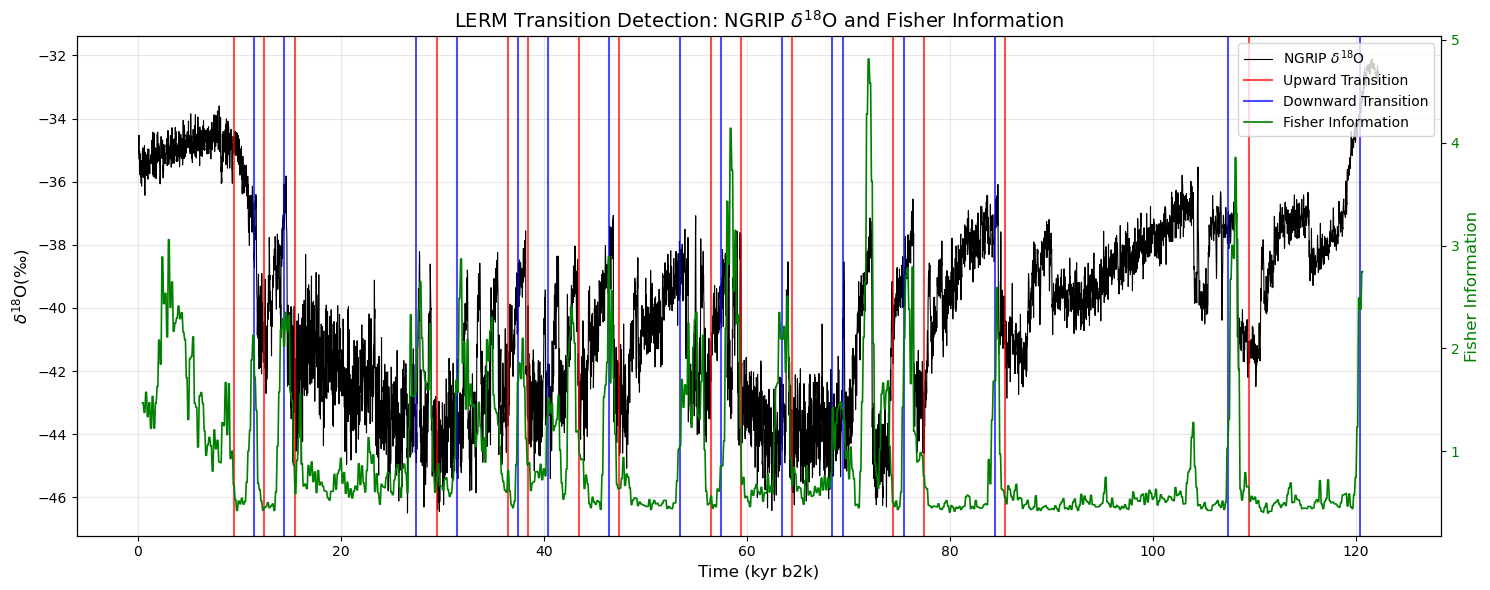

In [14]:
fig, ax1 = plt.subplots(figsize=(15,6))                                                    
ax1.plot(ngrip.time, ngrip.value, color='black', linewidth=0.8, label='NGRIP $\delta^{18}\mathrm{O}$')                                                                  
                                                                                            
ax1.set_xlabel('Time (kyr b2k)', fontsize=12)                                              
ax1.set_ylabel('$\delta^{18}\mathrm{O}(\u2030)$', fontsize=12, color='black')                      
                                                                                            
ax1.tick_params(axis='y', labelcolor='black')                                              
                                                                                            
ax2 = ax1.twinx()                                                                          
ax2.plot(NGRIP_lp_smooth.time, NGRIP_lp_smooth.value, color='green', linewidth=1.2,label='Fisher Information')                                                                
ax2.set_ylabel('Fisher Information', fontsize=12, color='green')                           
ax2.tick_params(axis='y', labelcolor='green')                                              
                                                                                                                          
first_up = True                                                                            
first_down = True                                                                          
for t, direction in zip(transitions.jump_times, transitions.jump_values):                  
    if direction > 0:                                                                      
        label = 'Upward Transition' if first_up else None                                  
        ax1.axvline(x=t, color='red', alpha=0.7, linewidth=1.5, label=label)               
        first_up = False                                                                   
    else:                                                                                  
        label = 'Downward Transition' if first_down else None                              
        ax1.axvline(x=t, color='blue', alpha=0.7, linewidth=1.5, label=label)              
        first_down = False                                                                 
                                                                                            
# Legend                                                                                   
lines1, labels1 = ax1.get_legend_handles_labels()                                          
lines2, labels2 = ax2.get_legend_handles_labels()                                          
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')                          
                                                                                            
ax1.set_title('LERM Transition Detection: NGRIP $\delta^{18}\mathrm{O}$ and Fisher Information', fontsize=14)                                                                 
                                                                                            
ax1.grid(True, alpha=0.3)                                                                  
plt.tight_layout()                                                                         
plt.show()

## Step 8: Alternative Detection Method (Kolmogorov-Smirnov Test)

The `kstest()` method applies the augmented **Kolmogorov-Smirnov (KS) test** to the smoothed Fisher Information series to detect statistically significant transitions. This is a complementary approach to the deterministic LERM method.

In [15]:
transitions_ks = NGRIP_lp_smooth.kstest(w_min=0.12, w_max=2.5, n_w=15,
                                        d_c=0.77, n_c=3, s_c=2, x_c=0.5)

### KS Test Results

The `print(transitions_ks)` command displays a **comprehensive summary** of all detected transitions from the KS test analysis.

The output below shows all transitions detected by the KS test, including:
- Statistical measures: D-statistics and p-values for each transition
- Transition count: 58 total (compared to 23 from LERM method)
- Direction classification: Upward vs. downward transitions

In [16]:
print(transitions_ks)

Deterministic Transition Detection Results - NGRIP Ice Core Data
+----------+---------------------+----------------+------------------+---------------------+
| Method   |   Total Transitions |   Upward Jumps |   Downward Jumps | Series Label        |
+==========+=====================+================+==================+=====================+
| KS test  |                  52 |             27 |               25 | NGRIP Ice Core Data |
+----------+---------------------+----------------+------------------+---------------------+

Transition Details:
  1. Time: 2.31 kyr b2k, Direction: Downward, d_statistics: 0.0000, p_values: 1.00
  2. Time: 4.71 kyr b2k, Direction: Upward, d_statistics: 0.8730, p_values: < 1e-12
  3. Time: 5.51 kyr b2k, Direction: Upward, d_statistics: 0.9375, p_values: < 1e-14
  4. Time: 9.35 kyr b2k, Direction: Upward, d_statistics: 0.5817, p_values: < 1e-4
  5. Time: 10.79 kyr b2k, Direction: Downward, d_statistics: 0.2601, p_values: 0.20
  6. Time: 11.11 kyr b2k, Direc

### Visualizing KS Test Transitions

This dual y-axis visualization shows the KS test detected transitions overlaid on both the Fisher Information and original climate data.

- **Black line (left y-axis)**: Original NGRIP $\delta^{18}O$ climate record  
                                                                            
- **Green line (right y-axis)**: Smoothed Fisher Information used for transition detection                                                          
                                                                            
- **Red vertical lines**: Upward transitions detected by KS test              
- **Blue vertical lines**: Downward transitions detected by KS test


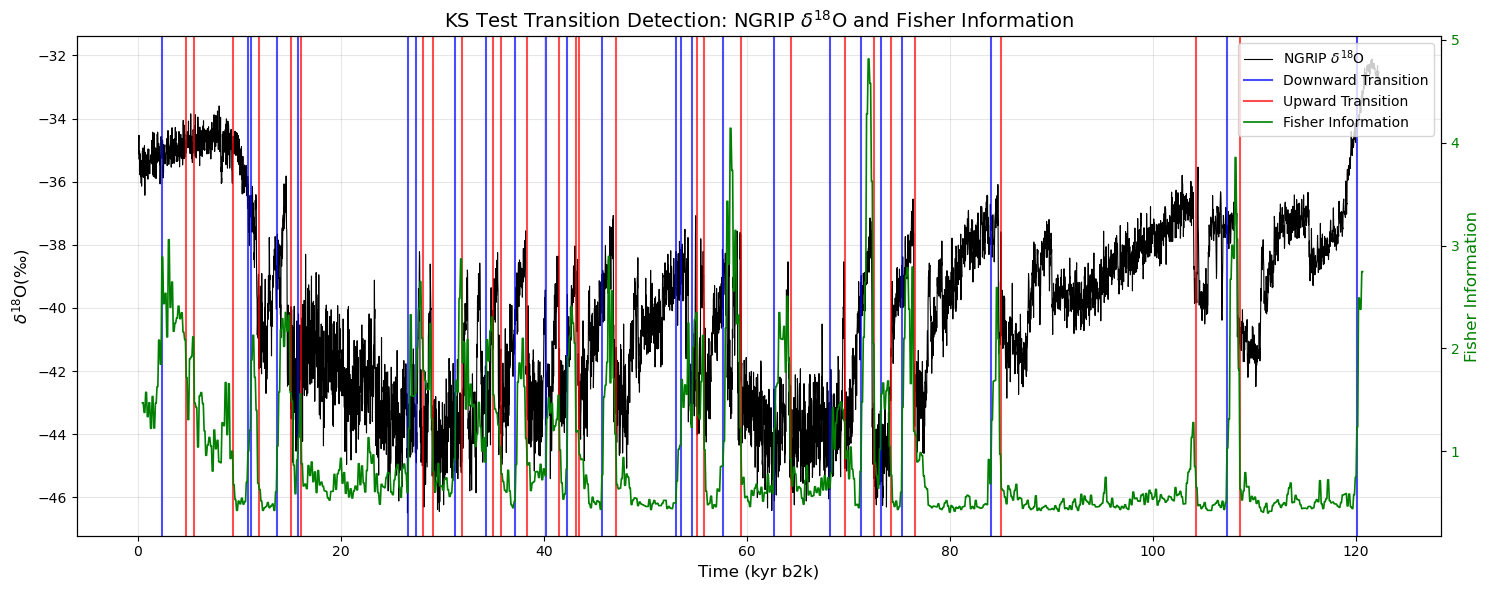

In [17]:
fig, ax1 = plt.subplots(figsize=(15,6))                                                    
ax1.plot(ngrip.time, ngrip.value, color='black', linewidth=0.8, label='NGRIP $\delta^{18}\mathrm{O}$')                                                                  
                                                                                            
ax1.set_xlabel('Time (kyr b2k)', fontsize=12)                                              
ax1.set_ylabel('$\delta^{18}\mathrm{O}(\u2030)$', fontsize=12, color='black')                      
                                                                                            
ax1.tick_params(axis='y', labelcolor='black')                                              
                                                                                            
ax2 = ax1.twinx()                                                                          
ax2.plot(NGRIP_lp_smooth.time, NGRIP_lp_smooth.value, color='green', linewidth=1.2,label='Fisher Information')                                                                
ax2.set_ylabel('Fisher Information', fontsize=12, color='green')                           
ax2.tick_params(axis='y', labelcolor='green')                                              
                                                                                                                          
first_up = True                                                                            
first_down = True                                                                          
for t, direction in zip(transitions_ks.jump_times, transitions_ks.jump_values):            
    if direction > 0:                                                                      
        label = 'Upward Transition' if first_up else None                                  
        ax1.axvline(x=t, color='red', alpha=0.7, linewidth=1.5, label=label)               
        first_up = False                                                                   
    else:                                                                                  
        label = 'Downward Transition' if first_down else None                              
        ax1.axvline(x=t, color='blue', alpha=0.7, linewidth=1.5, label=label)              
        first_down = False                                                                 
                                                                                            
# Legend                                                                                   
lines1, labels1 = ax1.get_legend_handles_labels()                                          
lines2, labels2 = ax2.get_legend_handles_labels()                                          
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')                          
                                                                                            
ax1.set_title('KS Test Transition Detection: NGRIP $\delta^{18}\mathrm{O}$ and Fisher Information', fontsize=14)                                                                 
                                                                                            
ax1.grid(True, alpha=0.3)                                                                  
plt.tight_layout()                                                                         
plt.show()